In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager
from sklearn import svm
from sklearn.datasets import make_blobs

In [3]:
X = 0.3 * np.random.randn(100, 2)+(5,5)
clf = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
clf.fit(X)
x_pred = clf.predict(X)

In [8]:
Y=np.c_[(5.2,5),(4,4),(5,4.2)].T
y_pred = clf.predict(Y)
y_pred

array([ 1, -1, -1], dtype=int64)

<ipython-input-9-4f0b264d1425>:33: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(XX, YY, -Z, cmap=plt.cm.Pastel1)


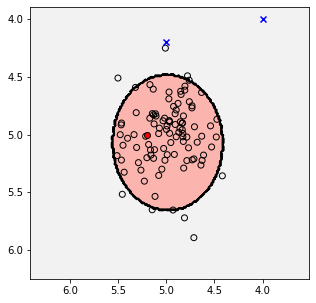

In [9]:
fig=plt.figure(1, figsize=(5, 5))
plt.clf()

#plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80,
#            facecolors='none', zorder=10, edgecolors='k')
#plt.scatter(X[:, 0], X[:, 1], c=y, zorder=10, cmap=plt.cm.Paired,
#            edgecolors='k')
plt.scatter(X[:, 0], X[:, 1], c='none', zorder=10, edgecolors='k')
#plt.scatter(Y[:, 0], Y[:, 1], c=y_pred, zorder=10, cmap=plt.cm.Paired, edgecolors='k')

markers = ['o', 'x', ',', '^', 'v', '*', '+', 'D']
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
m = 0
for i in set(y_pred):
    n = np.where(y_pred==i)
    plt.scatter(Y[n, 0], Y[n, 1], marker=markers[m], c=colors[m], zorder=10, edgecolors='k')
    m=m+1



plt.axis('tight')
x_min = min(X[:,0])+2#-3
x_max = max(X[:,0])-2#3
y_min = min(X[:,1])+2#-3
y_max = max(X[:,1])-2#3

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
#Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
Z = clf.predict(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
Z = Z.reshape(XX.shape)
plt.pcolormesh(XX, YY, -Z, cmap=plt.cm.Pastel1)
#plt.contour(XX, YY, Z, colors=['k', 'k', 'k'], linestyles=['--', '-', '--'],levels=[-.5, 0, .5])
plt.contour(XX, YY, Z, colors='k')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

#plt.xticks(())
#plt.yticks(())
plt.show()
fig.savefig("img.png")
fig.savefig("img.pdf")

In [11]:
Z

array([[-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1, -1, ..., -1, -1, -1]], dtype=int64)